<a href="https://colab.research.google.com/github/ibethatprettymothefucker/DataAnalysis/blob/main/3laba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №3: Понижение размерности

**Датасет:** BMW Used Car Sales  
**Описание:** Данные о продажах подержанных автомобилей BMW.  
Применяем методы снижения размерности (PCA, t-SNE, UMAP) для анализа скрытой структуры данных.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
PALETTE = 'tab10'

print("Все библиотеки загружены.")

Все библиотеки загружены.


In [ ]:
# Загрузка датасета
df = pd.read_csv('/bmw.csv')
print(f"Форма датасета: {df.shape}")
print(f"Период (года): {df['year'].min()} — {df['year'].max()}")
print(f"Количество уникальных моделей: {df['model'].nunique()}")

# Для анализа размерности отберем числовые признаки
NUMERIC_COLS = ['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']
df_num = df[NUMERIC_COLS].dropna()

df.head()

Форма датасета: (10781, 9)
Период (года): 1996 — 2020
Количество уникальных моделей: 24


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


---
## Задание 1. Геометрия данных в пространстве признаков

In [ ]:
print("=" * 50)
print("Число объектов: ", df_num.shape[0])
print("Число признаков:", df_num.shape[1])
print("=" * 50)

print("\nОписательные статистики:")
display(df_num.describe())

Число объектов:  10781
Число признаков: 6

Описательные статистики:


,year,price,mileage,tax,mpg,engineSize
count,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000
mean,2017.078935,22733.408867,25496.986550,131.702068,56.399035,2.167767
std,2.349038,11415.528189,25143.192559,61.510755,31.336958,0.552054
min,1996.000000,1200.000000,1.000000,0.000000,5.500000,0.000000
25%,2016.000000,14950.000000,5529.000000,135.000000,45.600000,2.000000
50%,2017.000000,20462.000000,18347.000000,145.000000,53.300000,2.000000
75%,2019.000000,27940.000000,38206.000000,145.000000,62.800000,2.000000
max,2020.000000,123456.000000,214000.000000,580.000000,470.800000,6.600000


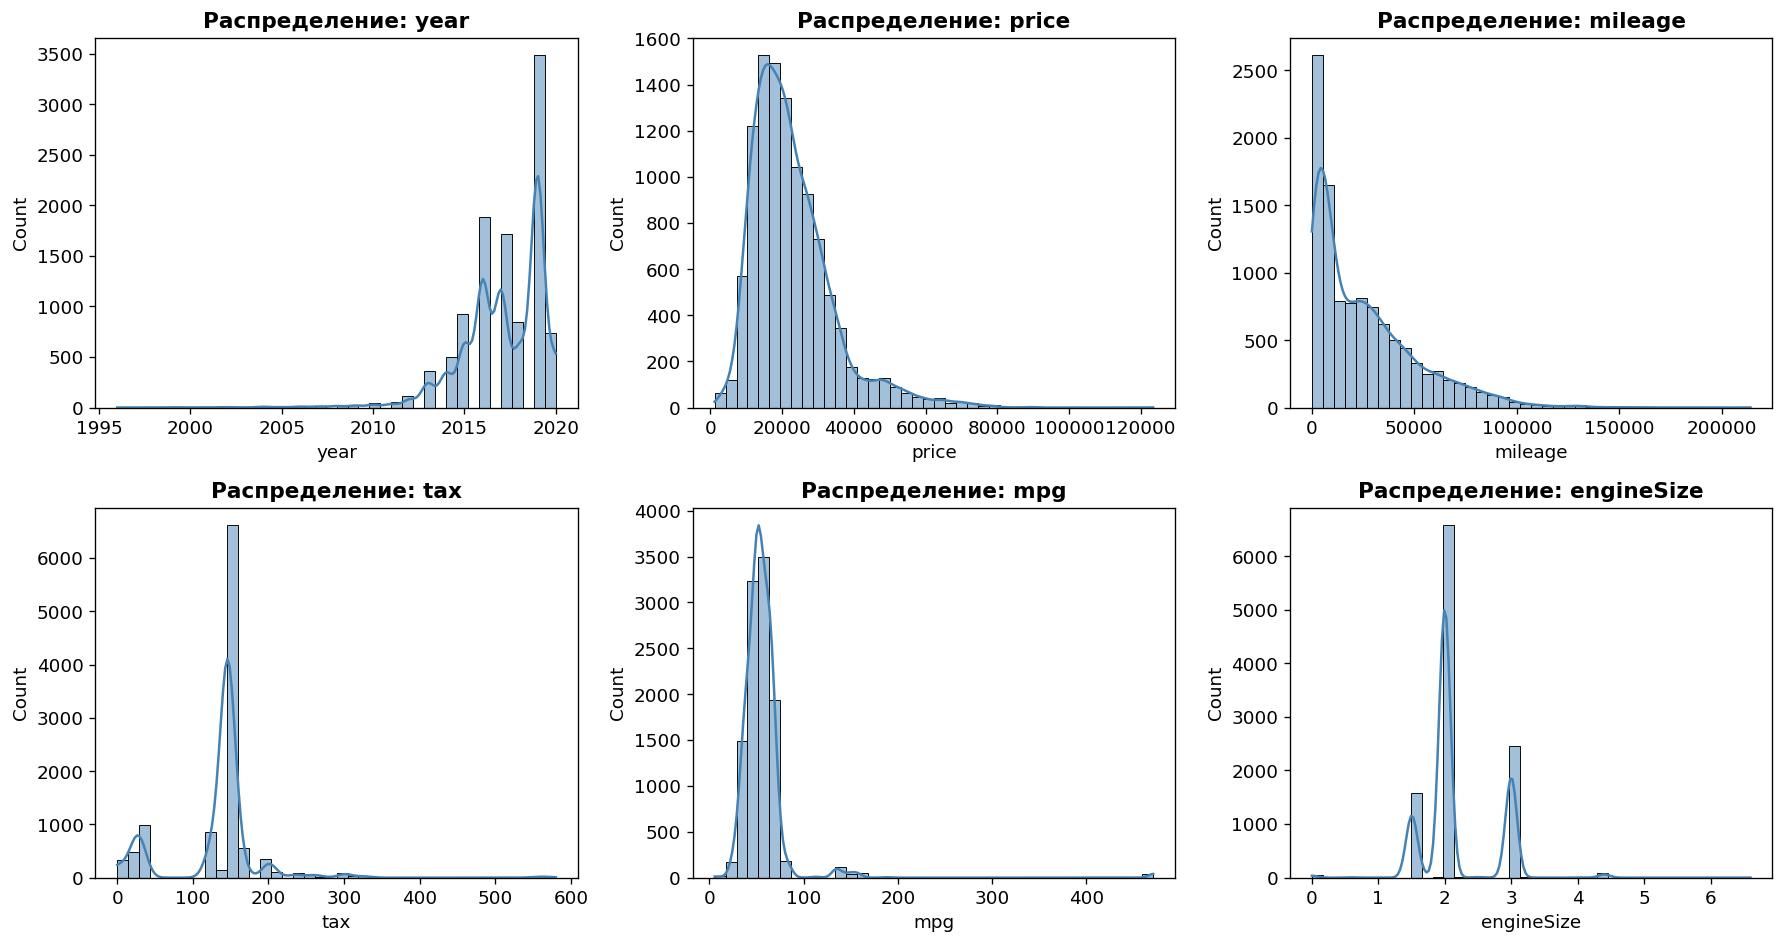

In [ ]:
# Построение гистограмм распределения
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    sns.histplot(df_num[col], bins=40, kde=True, color='steelblue', ax=axes[i])
    axes[i].set_title(f'Распределение: {col}', fontweight='bold')

plt.tight_layout()
plt.show()

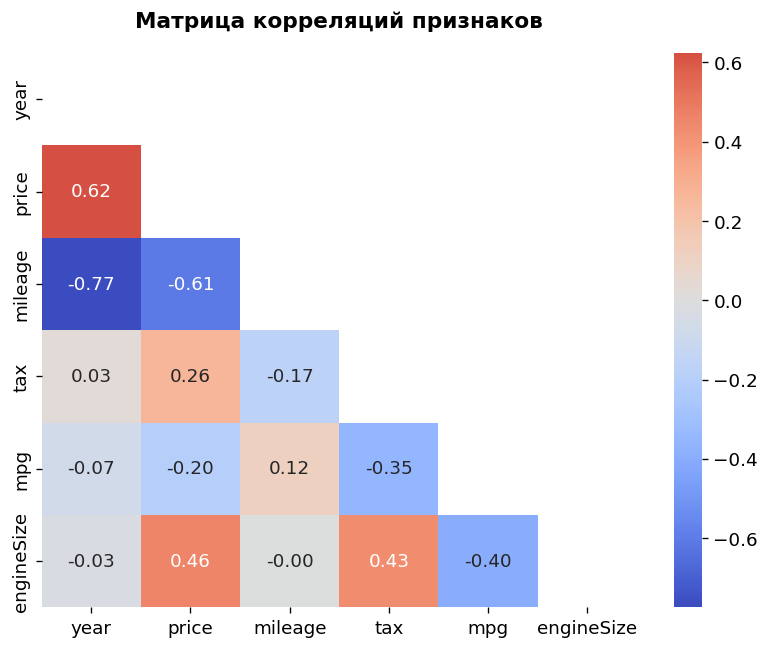

In [ ]:
# Построение матрицы корреляций
plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(df_num.corr(), dtype=bool))
sns.heatmap(df_num.corr(), mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Матрица корреляций признаков', fontweight='bold', pad=15)
plt.show()


1. Наблюдается сильная отрицательная корреляция между пробегом (`mileage`) и годом выпуска (`year`), а также сильная положительная корреляция между годом выпуска и ценой (`price`).
2. Год выпуска и пробег сильно линейно зависимы, поскольку оба они отражают возраст и износ автомобиля, тем самым дублируя информацию.

---
## Задание 2. Реализация РСА

In [ ]:
# 1. Стандартизация данных
X = df[['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("1. Стандартизация: выполнена.")
print(f"Пример первой строки:\n{X_scaled[0].round(4)}\n")

# 2. Вычисление ковариационной матрицы
cov_matrix = np.cov(X_scaled.T, ddof=0)
print("2. Матрица ковариации (6x6):\n", cov_matrix.round(4), "\n")

#  Нахождение собственных значений и собственных векторов
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
print("3. Собственные значения (до сортировки):", eigenvalues.round(4), "\n")

#  Сортировка компонент по убыванию собственных значений
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
print("4. Отсортированные собственные значения:", eigenvalues.round(4), "\n")

# 5 Проекция на 2 компоненты
X_projected = X_scaled @ eigenvectors[:, :2]
print("5. Проекция на 2 компоненты. Размерность:", X_projected.shape)

1. Стандартизация: выполнена.
Пример первой строки:
[-1.3108 -1.0104  1.6534 -0.109   0.0383 -0.3039]

2. Матрица ковариации (6x6):
 [[ 1.      0.6238 -0.7744  0.0252 -0.0718 -0.0263]
 [ 0.6238  1.     -0.6054  0.2635 -0.2049  0.4602]
 [-0.7744 -0.6054  1.     -0.1707  0.1186 -0.0025]
 [ 0.0252  0.2635 -0.1707  1.     -0.3518  0.4296]
 [-0.0718 -0.2049  0.1186 -0.3518  1.     -0.3998]
 [-0.0263  0.4602 -0.0025  0.4296 -0.3998  1.    ]] 

3. Собственные значения (до сортировки): [0.2009 0.2193 0.6424 0.6997 1.6591 2.5787] 

4. Отсортированные собственные значения: [2.5787 1.6591 0.6997 0.6424 0.2193 0.2009] 

5. Проекция на 2 компоненты. Размерность: (10781, 2)


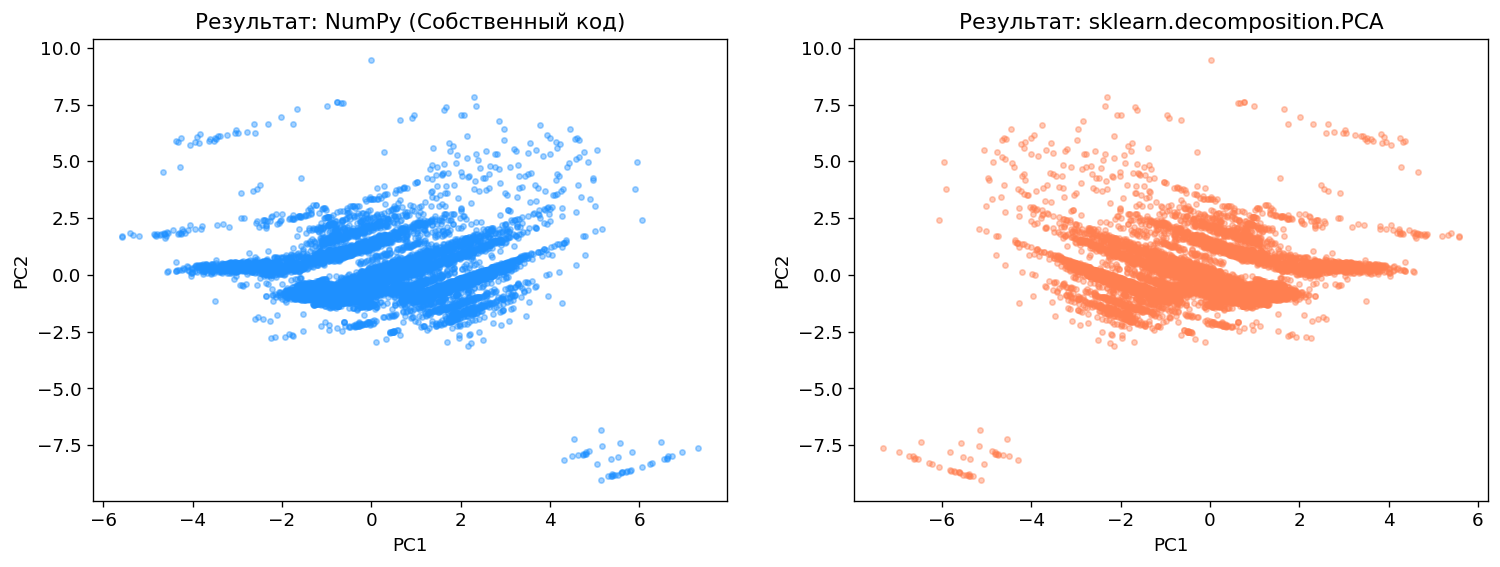

Корреляция для компоненты 1: 1.000000
Корреляция для компоненты 2: 1.000000

Вывод: Проекции идентичны.


In [ ]:
# Реализация через sklearn
pca_sk = PCA(n_components=2)
X_sklearn_pca = pca_sk.fit_transform(X_scaled)

# Визуальное сравнение
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.scatter(X_projected[:, 0], X_projected[:, 1], c='dodgerblue', s=10, alpha=0.4)
ax1.set_title('Результат: NumPy (Собственный код)')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')

ax2.scatter(X_sklearn_pca[:, 0], X_sklearn_pca[:, 1], c='coral', s=10, alpha=0.4)
ax2.set_title('Результат: sklearn.decomposition.PCA')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')

plt.show()

# Математическая проверка (корреляция между реализациями)
for i in range(2):
    corr = np.corrcoef(X_projected[:, i], X_sklearn_pca[:, i])[0, 1]
    print(f"Корреляция для компоненты {i+1}: {abs(corr):.6f}")

print("\nВывод: Проекции идентичны.")

### 2.1 Исследование объясненной дисперсии

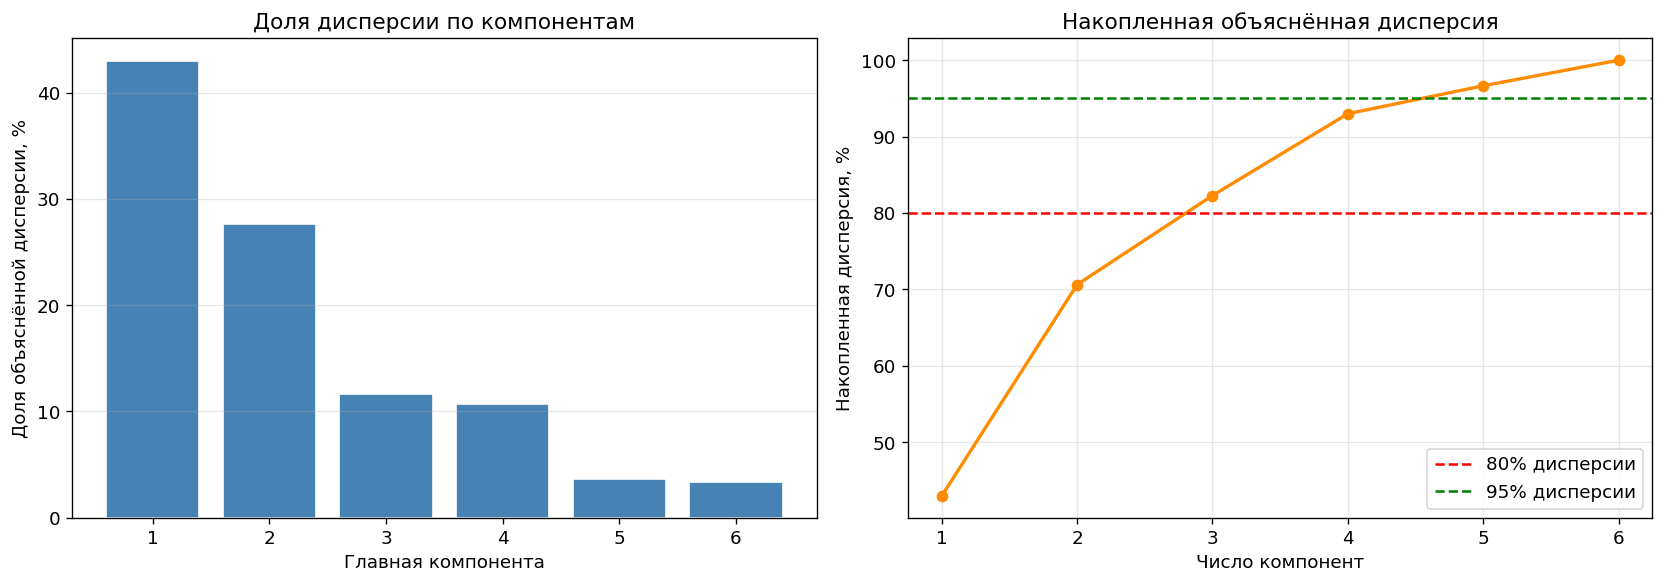

Сколько компонент объясняют 80% дисперсии? Ответ: 3 комп.
Сколько компонент объясняют 95% дисперсии? Ответ: 5 комп.


In [ ]:
explained_variance_ratio = eigenvalues / eigenvalues.sum()
cumulative_evr = np.cumsum(explained_variance_ratio)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Доля дисперсии
ax1.bar(range(1, len(explained_variance_ratio)+1), explained_variance_ratio * 100, color='steelblue', edgecolor='white')
ax1.set_xlabel('Главная компонента')
ax1.set_ylabel('Доля объяснённой дисперсии, %')
ax1.set_title('Доля дисперсии по компонентам')
ax1.grid(axis='y', alpha=0.3)

# Накопленная дисперсия
ax2.plot(range(1, len(cumulative_evr)+1), cumulative_evr * 100, 'o-', color='darkorange', linewidth=2)
ax2.axhline(80, color='red', linestyle='--', label='80% дисперсии')
ax2.axhline(95, color='green', linestyle='--', label='95% дисперсии')
ax2.set_xlabel('Число компонент')
ax2.set_ylabel('Накопленная дисперсия, %')
ax2.set_title('Накопленная объяснённая дисперсия')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

n_80 = np.argmax(cumulative_evr >= 0.80) + 1
n_95 = np.argmax(cumulative_evr >= 0.95) + 1

print(f"Сколько компонент объясняют 80% дисперсии? Ответ: {n_80} комп.")
print(f"Сколько компонент объясняют 95% дисперсии? Ответ: {n_95} комп.")

---
## Задание 3. Интерпретация главных компонент

In [ ]:
loadings = pd.DataFrame(
    eigenvectors[:, :3],
    index=NUMERIC_COLS,
    columns=['PC1', 'PC2', 'PC3']
)
print("Веса исходных признаков в первых трех главных компонентах:")
display(loadings.round(4))

Веса исходных признаков в первых трех главных компонентах:


,PC1,PC2,PC3
year,-0.4666,-0.4334,-0.1005
price,-0.5431,-0.0541,0.3890
mileage,0.4895,0.3621,0.1860
tax,-0.2925,0.4494,-0.0941
mpg,0.2694,-0.4354,0.7332
engineSize,-0.2992,0.5353,0.5075



*  Наибольший вклад вносят `year` (год выпуска), `price` (цена) и `mileage` (пробег). Они имеют максимальные по модулю веса в столбце PC1.

*  Наибольший вклад вносят `mpg` (расход топлива), `engineSize` (объем двигателя) и `tax` (налог).


* *PC1* — это компонента возраста и износа. Она разделяет старые дешевые машины с большим пробегом и новые дорогие авто.

* *PC2* — это компонента мощности и экономичности. Она разделяет малолитражные экономичные городские машины от мощных спортивных/тяжелых авто с большим объемом и расходом.

* *PC3* — это компонента технологичности и премиальности. Она отличает более дорогие и технологически продвинутые модели, которые могут сочетать относительно большой объем двигателя с хорошей топливной эффективностью.

---
## Задание 4. Визуализация и сравнение

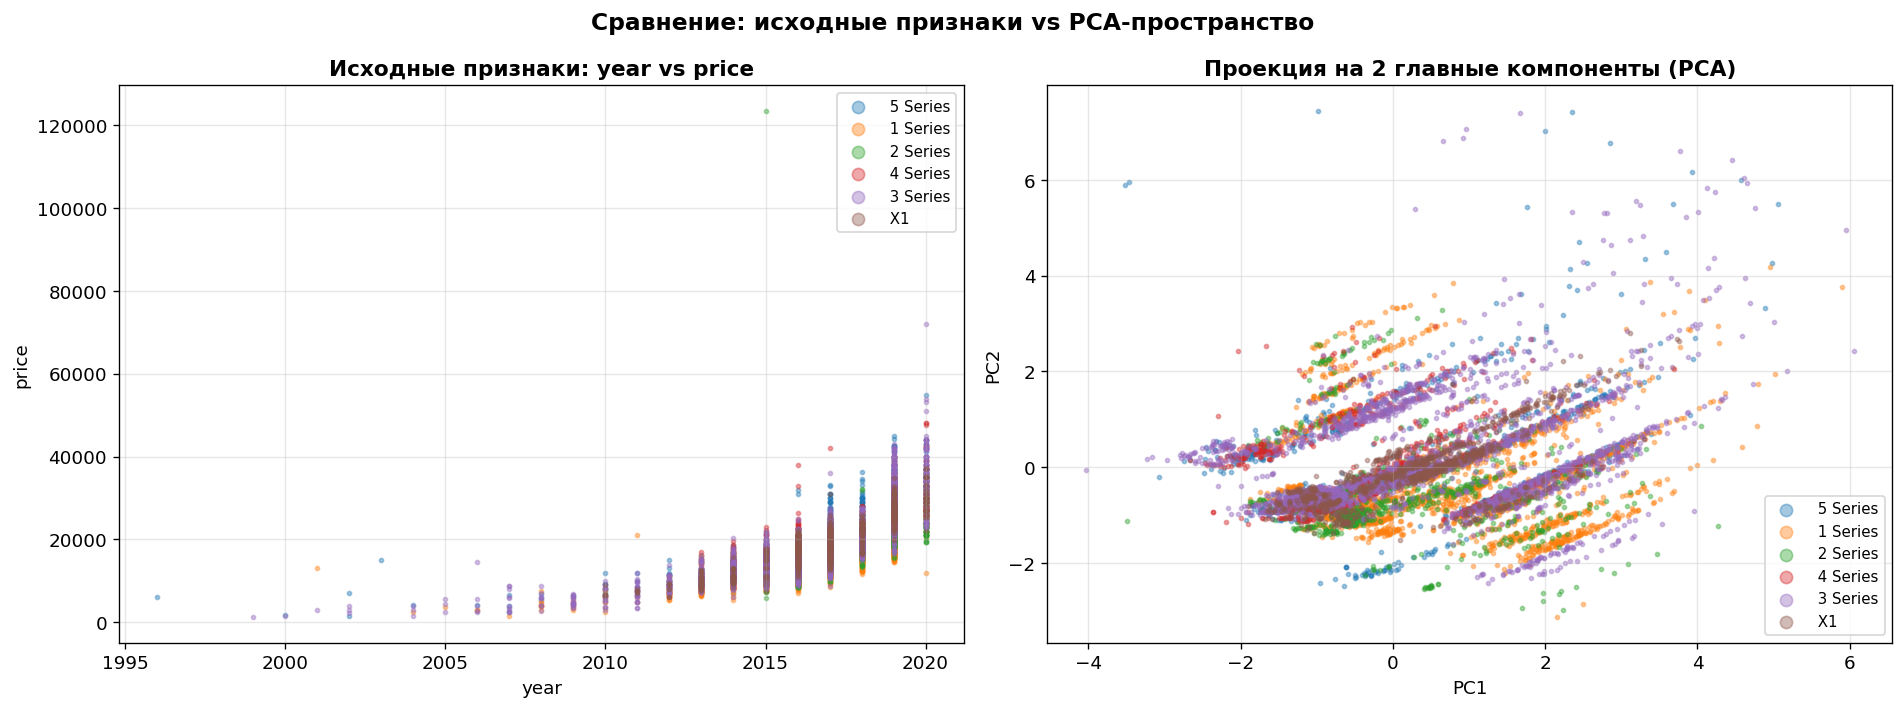

In [ ]:
# Возьмем топ-6 моделей для наглядности визуализации
top_models = df['model'].value_counts().nlargest(6).index
df_plot = df[df['model'].isin(top_models)].dropna().copy()
X_plot = scaler.transform(df_plot[NUMERIC_COLS])
X_pca_plot = X_plot @ eigenvectors[:, :2]

unique_models = df_plot['model'].unique()
palette = sns.color_palette(PALETTE, len(unique_models))
color_map = {m: palette[i] for i, m in enumerate(unique_models)}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Исходные признаки
for model in unique_models:
    mask = df_plot['model'] == model
    ax1.scatter(df_plot.loc[mask, 'year'], df_plot.loc[mask, 'price'],
                s=6, alpha=0.4, color=color_map[model], label=model)
ax1.set_xlabel('year')
ax1.set_ylabel('price')
ax1.set_title('Исходные признаки: year vs price', fontweight='bold')
ax1.legend(markerscale=3, fontsize=9)
ax1.grid(alpha=0.3)

# PCA
for model in unique_models:
    mask = df_plot['model'] == model
    ax2.scatter(X_pca_plot[mask, 0], X_pca_plot[mask, 1],
                s=6, alpha=0.4, color=color_map[model], label=model)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title('Проекция на 2 главные компоненты (PCA)', fontweight='bold')
ax2.legend(markerscale=3, fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle('Сравнение: исходные признаки vs PCA-пространство', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Сравнение структур:
Структура распределения объектов: В исходных координатах (year vs price) данные имеют форму "кривой": цена нелинейно падает с возрастом, и точки сильно наслаиваются друг на друга. В пространстве PCA данные распределены более равномерно по плоскости, облако точек «развернулось» вдоль осей максимальной дисперсии.

### Наличие групп и закономерностей:
<br> В исходных признаках модели  сильно перемешаны, так как мы видим только два параметра. В пространстве PCA группы становятся более обособленными

### Ответы на вопросы:
* Визуализация улучшилась. PCA позволил объединить информацию сразу из 6 признаков в две координаты. Благодаря этому на графике стало меньше перекрытий, а границы между дорогими/новыми и старыми/дешевыми моделями стали более четкими.

* В исходном пространстве признаки часто сильно коррелируют (как year и mileage), из-за чего информация дублируется и зашумляет график. PCA создает новые, ортогональные (независимые) оси, которые направлены туда, где данные имеют самый большой разброс. Таким образом, компоненты вытягивают скрытые различия между объектами, которые были распределены по многим мелким исходным признакам.

---
## Задание 5. Нелинейные методы снижения размерности

In [ ]:
# Для t-SNE и UMAP используем подвыборку для ускорения вычислений
N_SAMPLE = 2000
np.random.seed(42)
idx_sample = np.random.choice(len(X_scaled), N_SAMPLE, replace=False)
X_sample = X_scaled[idx_sample]
models_sample = df.iloc[df_num.index].iloc[idx_sample]['model'].values

print(f"Подвыборка для нелинейных методов: {N_SAMPLE} объектов")

Подвыборка для нелинейных методов: 2000 объектов


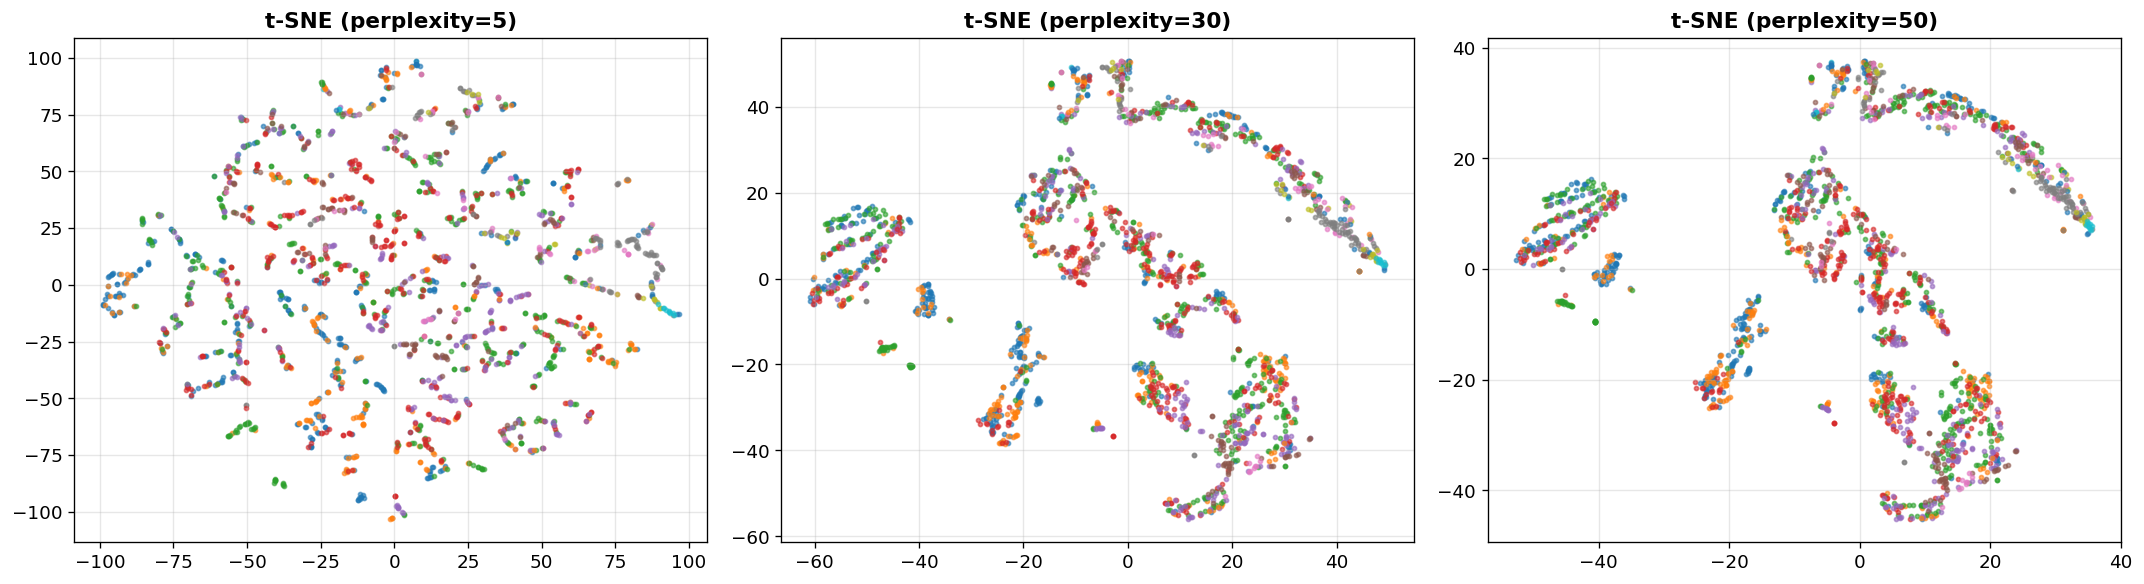

In [ ]:
# t-SNE с разными значениями perplexity
perplexities = [5, 30, 50]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, p in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=p, random_state=42)
    X_tsne = tsne.fit_transform(X_sample)

    for model in np.unique(models_sample):
        mask = models_sample == model
        axes[i].scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=6, alpha=0.6, label=model)

    axes[i].set_title(f't-SNE (perplexity={p})', fontweight='bold')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

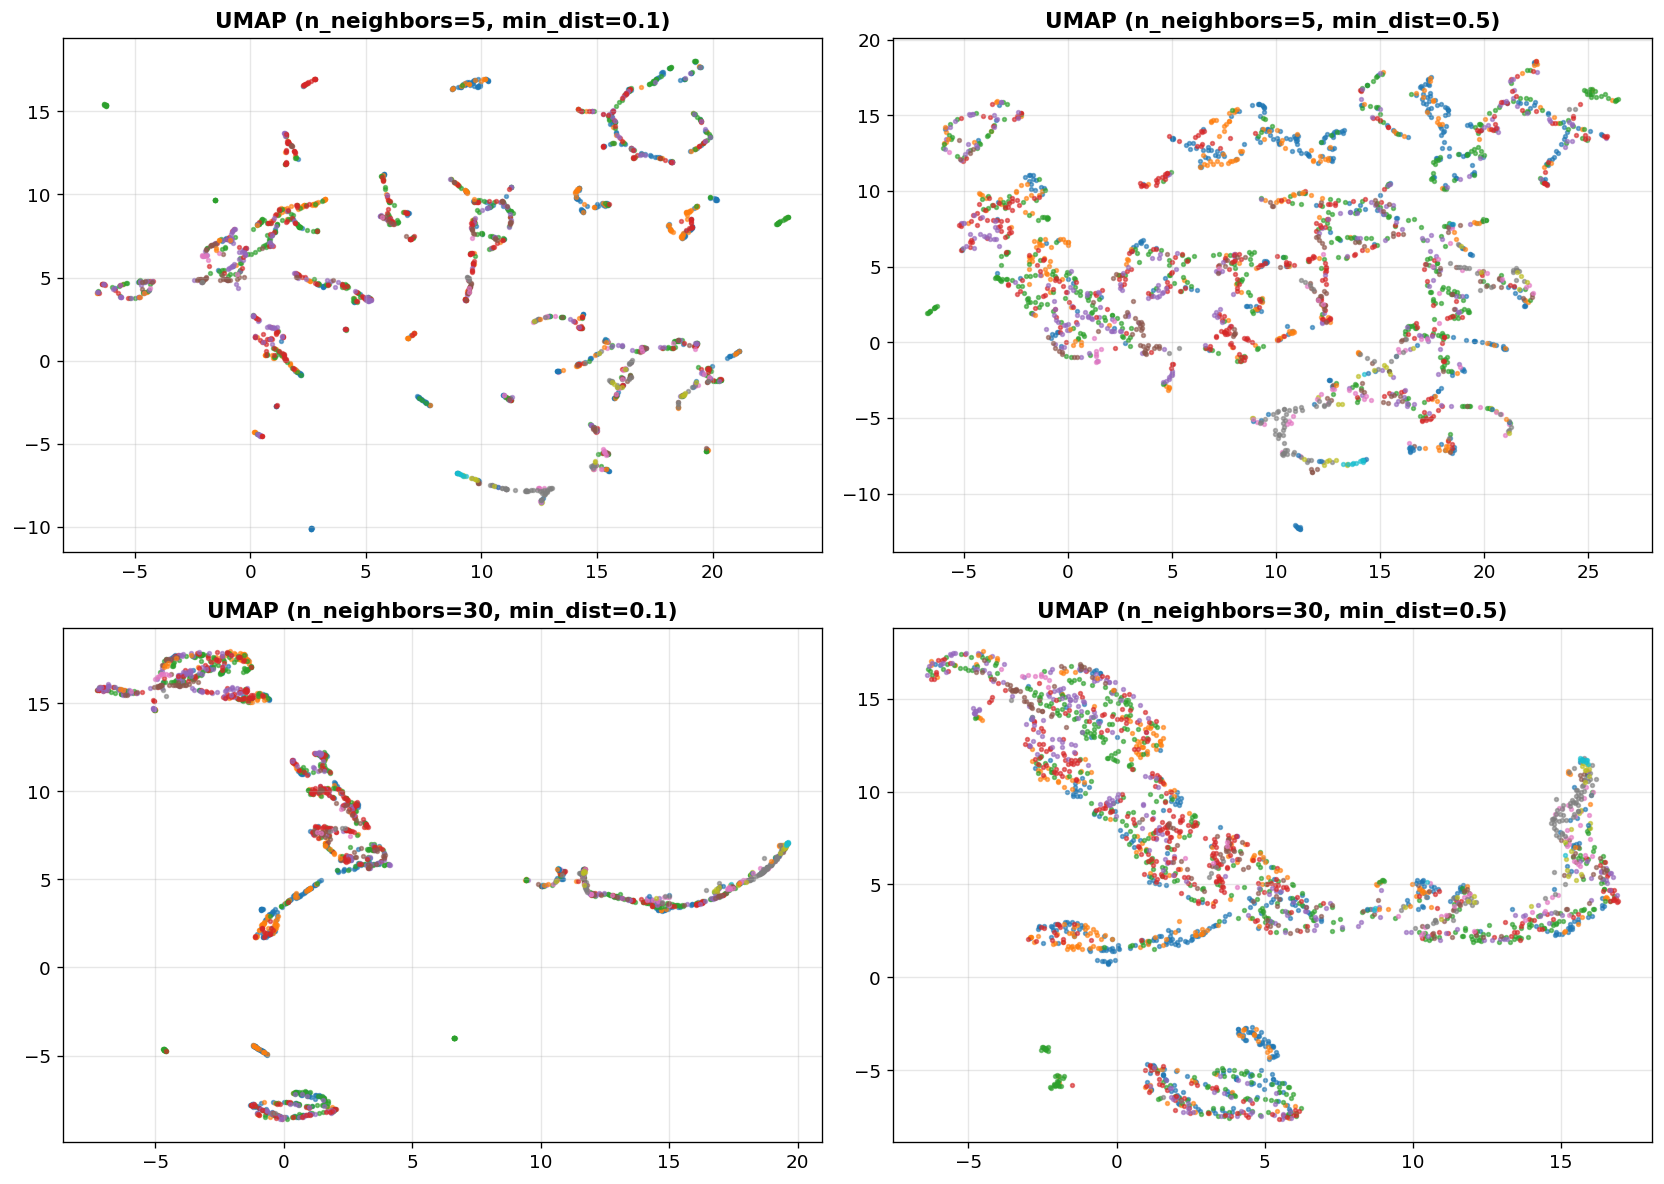

In [ ]:
import umap

# Сетка параметров для UMAP
neighbors_list = [5, 30]
min_dist_list = [0.1, 0.5]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
idx = 0

for n_nb in neighbors_list:
    for m_dist in min_dist_list:
        reducer = umap.UMAP(n_neighbors=n_nb, min_dist=m_dist, random_state=42)
        X_umap_tuned = reducer.fit_transform(X_sample)

        for model in np.unique(models_sample):
            mask = models_sample == model
            axes[idx].scatter(X_umap_tuned[mask, 0], X_umap_tuned[mask, 1], s=5, alpha=0.6, label=model)

        axes[idx].set_title(f'UMAP (n_neighbors={n_nb}, min_dist={m_dist})', fontweight='bold')
        axes[idx].grid(alpha=0.3)
        idx += 1

plt.tight_layout()
plt.show()

В t-SNE увеличение perplexity сглаживает картинку, превращая мелкие разрозненные островки в крупные и связные структуры. При малом perplexity данные распадаются на неинтерпретируемый шум.

В UMAP параметр n_neighbors отвечает за баланс локальной и глобальной структуры: малые значения дробят данные на мелкие кластеры, большие — сохраняют общую форму. Параметр min_dist определяет плотность упаковки точек: при 0.1 точки сгруппированы очень кучно, а при 0.5 они распределены равномерно.

UMAP при n_neighbors=30 и min_dist=0.1 показал наилучший результат — он сформировал четкие кластеры по моделям автомобилей, сохранив при этом общую логику их взаимного расположения.

---
## Задание 6. Оценка качества восстановления данных

In [ ]:
mse_table = []
k_values = [2, 5, 10, 15]

for k in k_values:
    # 1. Проекция на k компонент
    W_k = eigenvectors[:, :k]
    X_projected_k = X_scaled @ W_k

    # 2. Восстановление исходных данных
    X_reconstructed_k = X_projected_k @ W_k.T

    # 3. Расчет MSE
    mse = np.mean((X_scaled - X_reconstructed_k)**2)
    mse_table.append(mse)

# Вывод таблицы (как в PDF)
results_df = pd.DataFrame({
    'Число компонент': k_values,
    'Ошибка восстановления (MSE)': np.round(mse_table, 6)
})
print("Таблица ошибок восстановления:")
display(results_df)

# График: ошибка восстановления vs число компонент
plt.figure(figsize=(7, 4))
plt.plot(k_values, mse_table, 'o-', color='darkviolet', linewidth=2)
plt.title('Зависимость ошибки восстановления от числа компонент', fontweight='bold')
plt.xlabel('Число компонент (k)')
plt.ylabel('Ошибка восстановления (MSE)')
plt.grid(alpha=0.3)
plt.show()


1.  При малом количестве компонент мы отбрасываем оси, на которых распределена значительная доля вариабельности, теряя информацию.
2.  Чем больше направлений дисперсии мы берем, тем лучше сохраняется и восстанавливается исходное положение точек.
3.  При использовании всех 6 компонент ошибка восстановления становится равной 0.
4.  Сумма объясненной дисперсии всех компонент равна 100%. Ошибка восстановления прямо пропорциональна доле необъясненной дисперсии.
5.  Найти точку перегиба на графике MSE или графике накопленной дисперсии, где падение ошибки замедляется .

---
## Задание 7. Итоговый анализ

### Ответы на вопросы к Заданию 7
1. **Какую роль играет снижение размерности?** Помогает убрать избыточность (мультиколлинеарность), ускоряет обучение моделей и делает возможной визуализацию данных.
2. **Всегда ли уменьшение размерности полезно?** Нет, так как это неизбежно приводит к потере части информации, а новые оси становятся менее интерпретируемыми.
3. **В каких случаях линейные методы могут работать хуже нелинейных?** Когда данные расположены на сложных искривленных многообразиях (например, в виде спиралей). PCA их "сплющит", а t-SNE и UMAP смогут развернуть структуру.
4. **Преимущества и ограничения:**
   * **PCA:** быстрый и строго обратимый, но работает только с линейными структурами.
   * **t-SNE:** отлично сохраняет локальные скопления, но медленный и не сохраняет расстояния на глобальном масштабе.
   * **UMAP:** сохраняет и локальную, и глобальную структуру, работает быстрее t-SNE, но чувствителен к гиперпараметрам.